# Homework 2 — Regression
Задания: `course/cohorts/2026/homework/02-regression/homework.md`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'
cols = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']
df = pd.read_csv(url)[cols]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## Exploratory Data Analysis:Does `fuel_efficiency_mpg` have a long tail?

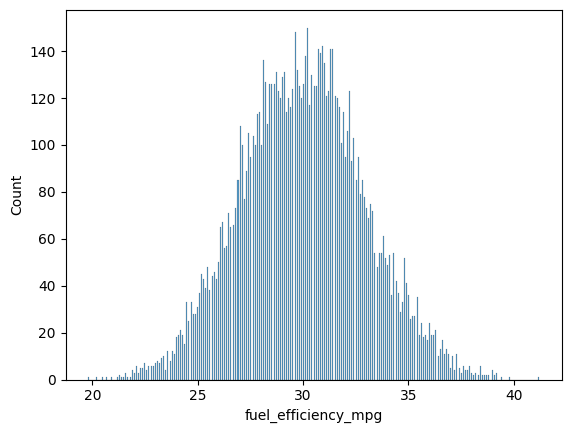

count    10000.000000
mean        29.997700
std          2.930245
min         19.800000
25%         28.000000
50%         30.000000
75%         31.900000
max         41.200000
Name: fuel_efficiency_mpg, dtype: float64

In [3]:
sns.histplot(df.fuel_efficiency_mpg, bins=450)
plt.show()
df.fuel_efficiency_mpg.describe()

## Q1. There's one column with missing values. What is it?

In [3]:
df.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Q2. What's the median (50% percentile) for variable 'horsepower'?

In [4]:
df.horsepower.median()

np.float64(254.0)

## Functions

In [5]:
base = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

def split(df, seed):
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]
    return df_train, df_val, df_test

def prepare_X(df, fill_value=0):
    return df[base].fillna(fill_value).values

def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T @ X + r * np.eye(X.shape[1])
    w_full = np.linalg.inv(XTX) @ X.T @ y
    return w_full[0], w_full[1:]

def rmse(y, y_pred):
    return np.sqrt(((y - y_pred) ** 2).mean())

def score(df_train, df_val, fill_value=0, r=0.0):
    w0, w = train_linear_regression(prepare_X(df_train, fill_value), df_train[target].values, r)
    y_pred = w0 + prepare_X(df_val, fill_value) @ w
    return rmse(df_val[target].values, y_pred)

## Q3.  fill it with 0 or with the mean?

In [7]:
df_train, df_val, df_test = split(df,42)
mean_hp = df_train.horsepower.mean()
print('with 0:   ', round(score(df_train, df_val, 0), 3))
print('with mean:', round(score(df_train, df_val, mean_hp), 3))

with 0:    2.205
with mean: 2.202


## Q4. Which `r` gives the best RMSE?

In [11]:
for r in [0, 0.001, 0.01, 0.1, 1, 5, 10, 100]:
    print(r, round(score(df_train, df_val, 0, r), 4))

0 2.2053
0.001 2.2053
0.01 2.2058
0.1 2.2241
1 2.3492
5 2.4094
10 2.4195
100 2.4292


## Q5.What's the standard deviation of all the scores?

In [13]:
scores = []
for seed in [0,1,2,3,4,5,6,7,8,9]:
    tr, va, _ = split(df, seed)
    scores.append(score(tr, va, 0))
print(np.round(scores, 3))
round(np.std(scores), 3)

[2.239 2.202 2.163 2.204 2.202 2.246 2.27  2.191 2.217 2.207]


0.029

## Q6. Train+val, seed 9, r=0.001

In [14]:
tr, va, te = split(df, 9)
full = pd.concat([tr, va])
round(score(full, te, 0, 0.001), 3)

2.236